In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
df = pd.read_csv("all_tickets_processed_improved_v3.xls")

In [3]:
df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Document     47837 non-null  str  
 1   Topic_group  47837 non-null  str  
dtypes: str(2)
memory usage: 14.5 MB


In [5]:
df.describe(include="all")

,Document,Topic_group
count,47837,47837
unique,47837,8
top,connection with icon icon dear please setup ic...,Hardware
freq,1,13617


In [6]:
df.shape

(47837, 2)

In [7]:
df.columns

Index(['Document', 'Topic_group'], dtype='str')

In [8]:
df.isnull().sum()

Document       0
Topic_group    0
dtype: int64

In [9]:
df = df.dropna()

In [10]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [12]:
df["Document"] = df["Document"].str.lower()

In [15]:
import re

df["Document"] = df["Document"].astype(str).str.lower()

df["Document"] = df["Document"].apply(
    lambda x: re.sub(r"[^a-zA-Z\s]", "", x)
)

In [16]:
X = df["Document"]
y = df["Topic_group"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [19]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](8,)","[5670.,1418.,8808.,...,5660.,1967.,2221.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](8,)","[-1.91,-3.3 ,-1.47,...,-1.91,-2.97,-2.85]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U21](8,)","['Access','Administrative rights','HR Support',...,'Miscellaneous', 'Purchase','Storage']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](8, 11414)","[[1. ,0.17,0. ,...,0. ,0.32,0. ], [0. ,0. ,0. ,...,0. ,0.07,0. ], [0.48,0. ,0.78,...,0.22,0. ,0. ], ..., [0.34,0. ,0. ,...,0.19,0. ,0. ], [0. ,0. ,0. ,...,0. ,0. ,0. ], [0. ,0. ,0. ,...,0. ,0. ,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](8, 11414)","[[ -9.65,-10.19,-10.34,...,-10.34,-10.06,-10.34], [ -9.74, -9.74, -9.74,..., -9.74, -9.68, -9.74], [-10.27,-10.67,-10.09,...,-10.47,-10.67,-10.67], ..., [-10.08,-10.37,-10.37,...,-10.2 ,-10.37,-10.37], [ -9.88, -9.88, -9.88,..., -9.88, -9.88, -9.88], [ -9.85, -9.85, -9.85,..., -9.85, -9.85, -9.85]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11414


In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.7313963210702341

                       precision    recall  f1-score   support

               Access       0.89      0.71      0.79      1455
Administrative rights       1.00      0.16      0.28       342
           HR Support       0.69      0.78      0.74      2107
             Hardware       0.63      0.90      0.74      2760
     Internal Project       0.99      0.36      0.53       451
        Miscellaneous       0.77      0.64      0.70      1400
             Purchase       0.99      0.82      0.90       497
              Storage       0.97      0.55      0.70       556

             accuracy                           0.73      9568
            macro avg       0.87      0.62      0.67      9568
         weighted avg       0.77      0.73      0.72      9568



In [ ]:
def assign_priority(ticket):
    ticket = ticket.lower()

    high_keywords = [
        "urgent", "critical", "server", "down", "cannot","can't", "cant", "not working","login failed", "login issue","login"
        "failed","locked","password","error", "crash", "hack", "payment failed",
    ]

    medium_keywords = [
        "issue", "problem", "warning",
        "slow", "delay", "unable"
    ]

    for word in high_keywords:
        if word in ticket:
            return "High"

    for word in medium_keywords:
        if word in ticket:
            return "Medium"

    return "Low"


df["Priority"] = df["Document"].apply(assign_priority)

df[["Document","Topic_group","Priority"]].head()

,Document,Topic_group,Priority
0,connection with icon icon dear please setup ic...,Hardware,Low
1,work experience user work experience user hi w...,Access,Low
2,requesting for meeting requesting meeting hi p...,Hardware,Low
3,reset passwords for external accounts re expir...,Access,Medium
4,mail verification warning hi has got attached ...,Miscellaneous,Medium


In [23]:
def predict_ticket(ticket):

    clean = ticket.lower()

    clean = vectorizer.transform([clean])

    category = model.predict(clean)[0]

    priority = assign_priority(ticket)

    print("Ticket :", ticket)
    print("Category :", category)
    print("Priority :", priority)

In [24]:
predict_ticket("My laptop crashes every time I start Windows.")

Ticket : My laptop crashes every time I start Windows.
Category : Hardware
Priority : High


<Figure size 1000x800 with 0 Axes>

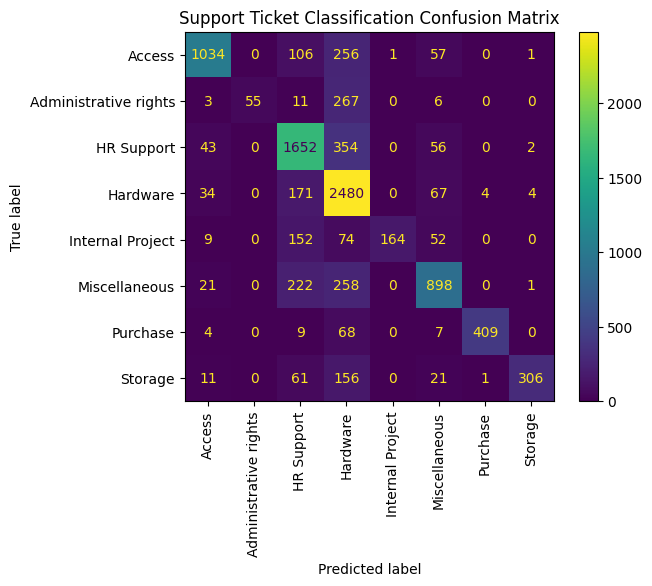

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    xticks_rotation=90
)

plt.title("Support Ticket Classification Confusion Matrix")
plt.show()

## Workflow

Customer Ticket

        ↓
        
Text Cleaning

        ↓
        
TF-IDF Vectorization

        ↓
        
Multinomial Naive Bayes

        ↓
        
Category Prediction

        ↓
        
Priority Assignment

## Business Problem

Large organizations receive hundreds of customer support tickets daily.

Manually categorizing tickets takes time and delays responses.

This project automatically classifies each ticket into the appropriate department and assigns a priority level so urgent issues can be resolved faster.

## Model Used

• TF-IDF converts ticket text into numerical vectors.

• Multinomial Naive Bayes learns the relationship between ticket words and ticket categories.

• The trained model predicts the most likely category for unseen tickets.

## Model Performance

Accuracy : 73.13%

The model performs well across most ticket categories.

Categories like Purchase, Hardware and Access achieve high prediction accuracy.

The system can significantly reduce manual ticket sorting.

## Insights

• Purchase tickets are classified very accurately.
    
• Hardware tickets achieve high recall.
    
• Administrative Rights has fewer samples, making prediction harder.
    
• Overall model accuracy is suitable for automatic ticket routing.